# Incident Prediction from Time-Series Metrics

Our task requires implementation of a machine learning model that predicts whether an incident will occur in the next **H time steps** based on the previous **W observations** of system metrics.

## Problem Formulation

Let define **m** system metrics at time **t** as $X_t = (X_t^1, X_t^2, ..., X_t^m)$. For a window of time size W the model input will be:..
$$
[X_{t-W+1}, ..., X_t].
$$
The model predicts whether an incident will occur within the next H time steps:
$$
y_t = \left\{ \begin{array}{l}
1 \mbox{ if an inciden occurs in } [t+1, t+H], \\
0 \mbox{ otherwise. }
\end{array}\right.
$$
This converts the time-series prediction problem into a supervised classification problem.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

np.random.seed(123)

## Synthetic Dataset

We generate a synthetic multivariate time-series dataset representing system monitoring metrics. The dataset contains the following metrics:
- CPU usage,
- memory usage,
- request latency,
- error rate.
 
As incidents we call situations when abnormal patterns occur, for example:
- CPU spike,
- latency increase,
- error rate surge.

In [3]:
n = 5000
t = np.arange(n)

cpu = 50 + 10*np.sin(t/50) + np.random.normal(0,3,n)
memory = 60 + 8*np.sin(t/60) + np.random.normal(0,2,n)
latency = 100 + 15*np.sin(t/40) + np.random.normal(0,5,n)
errors = np.random.poisson(1,n)
incident = np.zeros(n)

for i in range(100, n, 400):
    cpu[i:i+20] += 40
    latency[i:i+20] += 80
    errors[i:i+20] += 10
    incident[i:i+20] = 1

df = pd.DataFrame({
    "cpu": cpu,
    "memory": memory,
    "latency": latency,
    "errors": errors,
    "incident": incident
})

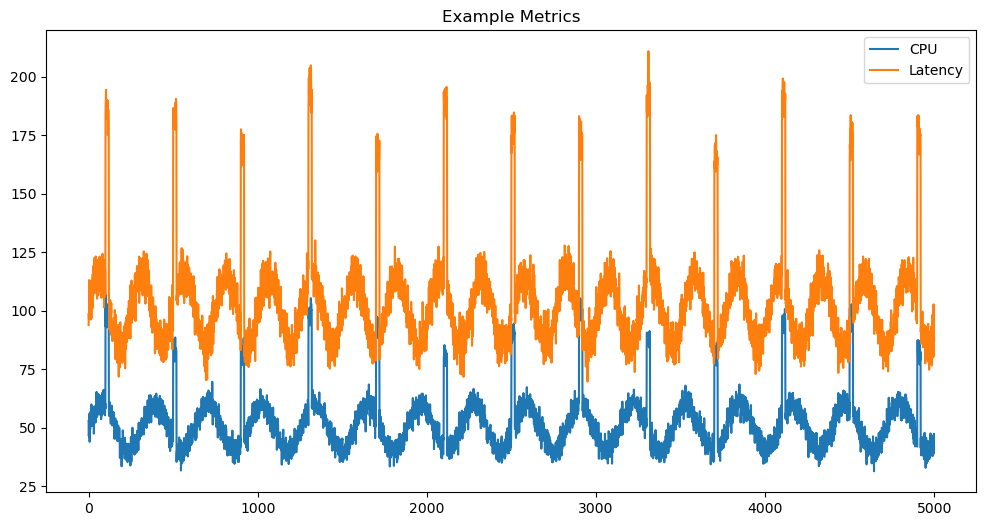

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df.cpu, label="CPU")
plt.plot(df.latency, label="Latency")
plt.legend()
plt.title("Example Metrics")
plt.show()